# Phase 1: Gene Expression Clustering for Cancer Subtype Discovery

**Cambridge Data Science & ML Accelerator — Self-Directed Mini-Project**

## Goal
Explore whether unsupervised clustering can identify distinct cancer types purely from gene expression patterns, without ever being told the diagnosis — and then check how well the discovered clusters match the real, known cancer types.

## Research Question
Can unsupervised clustering of RNA-Seq gene expression data separate patients into groups that align with their actual tumor type, using no diagnostic labels during clustering?

## Dataset
- **Source:** UCI Machine Learning Repository — Gene Expression Cancer RNA-Seq
- **Origin:** The Cancer Genome Atlas (TCGA) Pan-Cancer Analysis Project
- **Size:** 801 patients × 20,531 genes
- **Tumor types covered:** BRCA (breast), KIRC (kidney), COAD (colon), LUAD (lung), PRAD (prostate)

## Why This Project
Building on Course 1 clustering techniques (K-means, hierarchical clustering, PCA, t-SNE) applied previously to customer segmentation, this project applies the same toolkit to biological data — with the added step of validating unsupervised clusters against ground-truth diagnostic labels.

## Dataset

The dataset was sourced from the UCI Machine Learning Repository (Gene Expression Cancer RNA-Seq), originally derived from the TCGA Pan-Cancer Analysis Project. It contains 801 patient tumor samples, each described by expression levels across 20,531 genes, covering five cancer types: BRCA, KIRC, COAD, LUAD, and PRAD.

In [ ]:
import urllib.request
import zipfile
import tarfile
import os

# Step 1: Download the zip file directly from UCI
url = "https://archive.ics.uci.edu/static/public/401/gene+expression+cancer+rna+seq.zip"
urllib.request.urlretrieve(url, "gene_expression.zip")
print("Downloaded.")

# Step 2: Unzip it
with zipfile.ZipFile("gene_expression.zip", "r") as zip_ref:
    zip_ref.extractall(".")

# Step 3: Find and extract the tar.gz
for f in os.listdir("."):
    print(f)

Downloaded.
.config
TCGA-PANCAN-HiSeq-801x20531.tar.gz
TCGA-PANCAN-HiSeq-801x20531
gene_expression.zip
sample_data


In [ ]:
import tarfile

with tarfile.open("TCGA-PANCAN-HiSeq-801x20531.tar.gz", "r:gz") as tar:
    tar.extractall(".")

import os
for root, dirs, files in os.walk("."):
    for f in files:
        if 'sample_data' not in root and '.config' not in root:
            print(os.path.join(root, f))

/tmp/ipykernel_580/1457190396.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(".")


./TCGA-PANCAN-HiSeq-801x20531.tar.gz
./gene_expression.zip
./TCGA-PANCAN-HiSeq-801x20531/labels.csv
./TCGA-PANCAN-HiSeq-801x20531/data.csv


## Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd

X = pd.read_csv("TCGA-PANCAN-HiSeq-801x20531/data.csv", index_col=0)
y = pd.read_csv("TCGA-PANCAN-HiSeq-801x20531/labels.csv", index_col=0)

print("Features shape:", X.shape)
print("Targets shape:", y.shape)

Features shape: (801, 20531)
Targets shape: (801, 1)


The dataset has 801 patients and 20,531 gene expression features — far more columns than rows, the opposite structure to the customer segmentation dataset, which had many more rows than features. This matters later on, as distance-based clustering becomes unreliable in very high-dimensional spaces with relatively few samples, so dimensionality reduction will be a necessary step before clustering.

In [ ]:
# Descriptive statistics
print(X.head())
print(X.describe())

          gene_0    gene_1    gene_2  ...  gene_20528  gene_20529  gene_20530
sample_0     0.0  2.017209  3.265527  ...    8.921326    5.286759         0.0
sample_1     0.0  0.592732  1.588421  ...    9.397854    2.094168         0.0
sample_2     0.0  3.511759  4.327199  ...   10.090470    1.683023         0.0
sample_3     0.0  3.663618  4.507649  ...    9.684365    3.292001         0.0
sample_4     0.0  2.655741  2.821547  ...    9.461191    5.110372         0.0

[5 rows x 20531 columns]
           gene_0      gene_1      gene_2  ...  gene_20528  gene_20529  gene_20530
count  801.000000  801.000000  801.000000  ...  801.000000  801.000000  801.000000
mean     0.026642    3.010909    3.095350  ...    9.590726    5.528177    0.095411
std      0.136850    1.200828    1.065601  ...    0.563849    2.073859    0.364529
min      0.000000    0.000000    0.000000  ...    7.864533    0.593975    0.000000
25%      0.000000    2.299039    2.390365  ...    9.244219    4.092385    0.000000
50%     

Genes are labelled with dummy identifiers rather than real gene names, so the focus here is on structure rather than biological interpretation. The summary statistics show expression values vary considerably in scale across genes, meaning the data will need to be standardised before PCA or clustering to prevent genes with larger raw values from dominating the analysis.

In [ ]:
# Check for missing values
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum().sum())

Missing values in X: 0
Missing values in y: 0


No missing values were found in either the features or the labels, so the dataset can move directly to scaling without needing imputation.

In [ ]:
print(y.value_counts())

Class
BRCA     300
KIRC     146
LUAD     141
PRAD     136
COAD      78
Name: count, dtype: int64


The five cancer types are not perfectly balanced, though each is reasonably represented. This is worth keeping in mind later, as class imbalance can influence how cluster-to-label comparisons are interpreted.

## Feature Engineering & Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)
print(X_scaled[:5, :5])

(801, 20531)
[[-0.19479935 -0.82802988  0.15980044 -1.94827735  1.22157468]
 [-0.19479935 -2.01501735 -1.415042    1.35310867 -0.3765177 ]
 [-0.19479935  0.41734754  1.15673547  0.24980678  0.11283193]
 [-0.19479935  0.54388843  1.32618236 -0.09905252  0.75574091]
 [-0.19479935 -0.29595452 -0.25710728 -0.28641317 -0.14884307]]


One interesting thing worth noticing: the first column shows -0.19479935 repeated identically across all 5 rows. That gene (probably gene_0, the first column) likely has very low or zero variance across patients.

## Dimensionality Reduction (PCA)

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Shape after PCA:", X_pca.shape)
print("Total variance explained by 50 components:", pca.explained_variance_ratio_.sum())

Shape after PCA: (801, 50)
Total variance explained by 50 components: 0.6367085702811444


This means 50 components captured about 63.7% of the total variation in the original 20,531 genes. However, we can plot a curve to find out how many components needed for 80% and 90%.

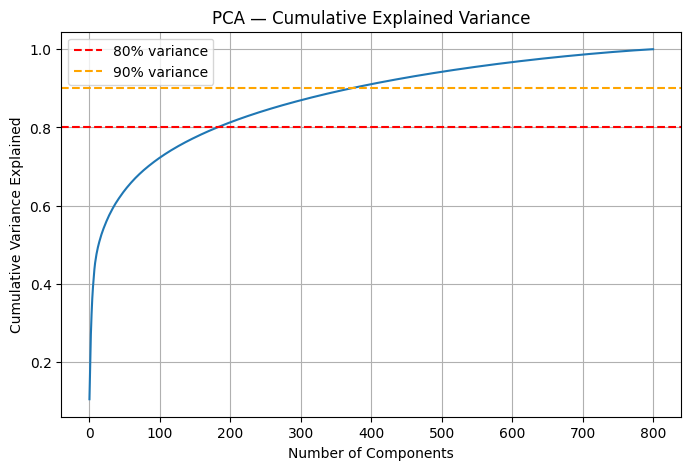

Components needed for 80% variance: 183
Components needed for 90% variance: 373


In [ ]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('PCA — Cumulative Explained Variance')
plt.axhline(y=0.80, color='r', linestyle='--', label='80% variance')
plt.axhline(y=0.90, color='orange', linestyle='--', label='90% variance')
plt.legend()
plt.grid(True)
plt.show()

# Find how many components needed for 80% and 90%
n_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Components needed for 80% variance: {n_80}")
print(f"Components needed for 90% variance: {n_90}")

In [ ]:
pca = PCA(n_components=183, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Shape after PCA:", X_pca.shape)
print("Variance explained:", pca.explained_variance_ratio_.sum())

Shape after PCA: (801, 183)
Variance explained: 0.7983482154355203


183 components were selected to preserve approximately 80% of the total variance in the dataset, following common practice in PCA-based dimensionality reduction. This reduces the feature space from 20,531 genes down to 183 components while retaining most of the meaningful variation, striking a balance between avoiding the curse of dimensionality and minimising information loss. In a clinical or bioinformatics research setting, this choice would ideally be validated further with domain expertise or downstream model performance testing — a limitation of this self-directed exercise.

## Clustering

### Finding the Optimal Number of Clusters

Before running anything, it's worth stating what I expect. Since this dataset has five known cancer types (BRCA, KIRC, COAD, LUAD, PRAD), the obvious guess is that the optimal k will come out as 5. But that's not guaranteed — clustering has no idea what the diagnostic labels are, it's only looking at patterns in gene expression itself. It's entirely possible some cancer types overlap in their expression profiles, or that one type actually splits into distinct sub-groups. If either is true, the optimal k could end up being something other than 5.

I'm using Silhouette score and the Elbow method together here, the same cross-checking approach from the customer segmentation project, rather than trusting a single method on its own.

#### Silhouette Score Method

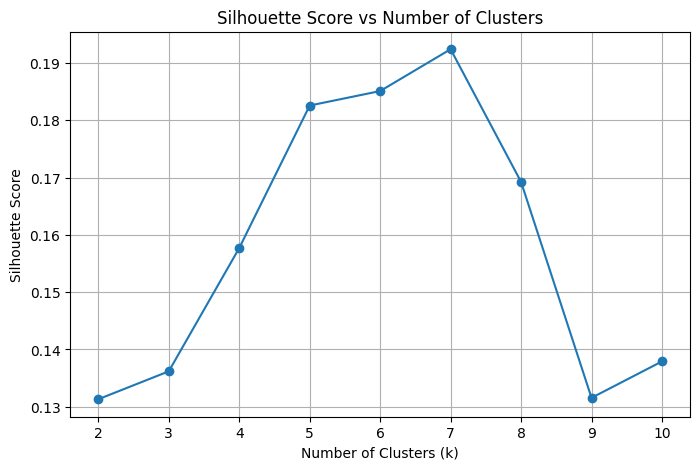

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    wcss.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.grid(True)
plt.show()

The Silhouette score actually peaks at k=7, not 5 as expected. That's worth taking seriously rather than dismissing — it suggests the natural structure in the gene expression data might not line up perfectly with the five diagnostic labels, possibly because some cancer types share overlapping expression patterns, or because a single type contains real sub-groups. Silhouette alone isn't enough to settle this though, so the Elbow method comes next as an independent check before deciding on a final k.

#### Elbow Method

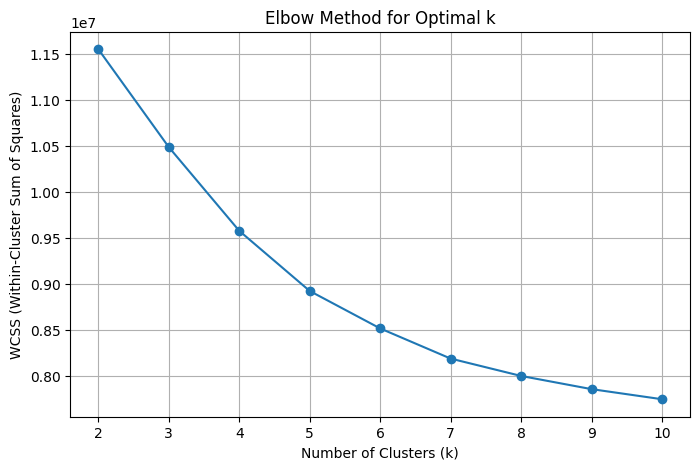

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

The Elbow plot doesn't show one clear, sharp bend, unlike the customer segmentation project where the elbow was more obvious. WCSS drops fairly steadily up to around k=5-6, then flattens out more gradually from there. If forced to pick a single point, k=6 seems like a reasonable estimate, sitting between the original expectation of 5 and the Silhouette method's peak of 7.

Since Silhouette and Elbow don't fully agree, a third independent method is needed before settling on a final k. Hierarchical clustering and a dendrogram are used next, following the same three-way validation approach used in the customer segmentation project.

#### Hierarchical Clustering (Dendrogram)

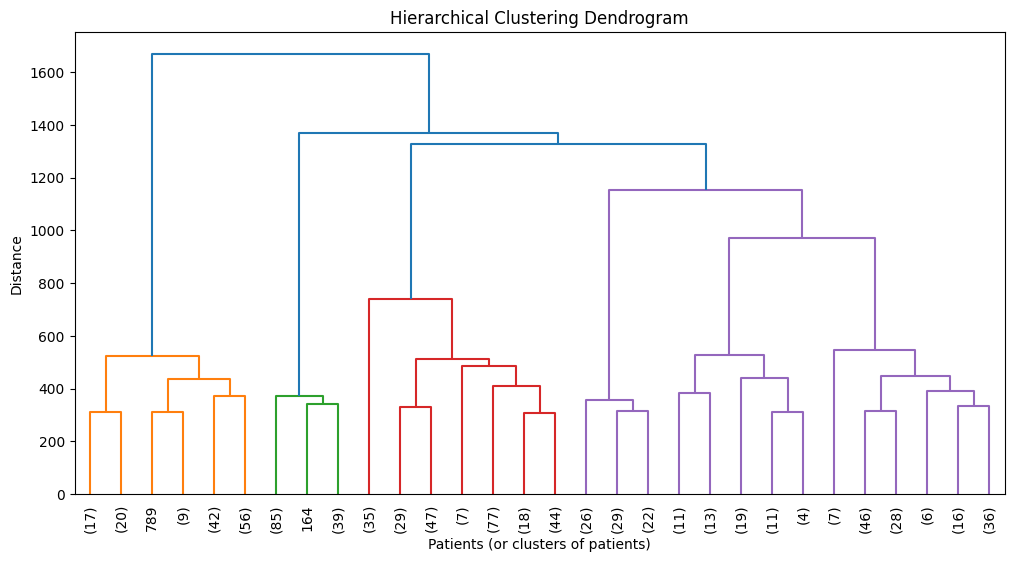

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(X_pca, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.xlabel('Patients (or clusters of patients)')
plt.ylabel('Distance')
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

Three different methods gave three different answers:
- Silhouette pointed to 7,
- The Elbow method leaned toward 5-6,
- The dendrogram's clearest top-level split suggested 3.

None of them converged cleanly on 5, which is worth reporting honestly rather than glossing over.

Even so, k=5 is used for the final clustering — not because the internal metrics agreed on it, but because it directly matches the number of known cancer types in the dataset. The goal of this project isn't to find whatever k is mathematically optimal, it's to test a specific question: does unsupervised clustering, given no access to diagnosis, naturally rediscover the five known cancer types anyway? Answering that properly means clustering with k=5 and checking how well the result lines up with the true labels, rather than defaulting to whichever k scored best on an internal metric.

### Final Clustering (k=5)

In [ ]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_pca)

print("Cluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())

Cluster sizes:
0     74
1    144
2    134
3    250
4    199
Name: count, dtype: int64


This spread makes sense, and if we check back against y.value_counts() from earlier, these numbers roughly mirror the actual sizes of each cancer type in the original labels (some cancer types just have more patients than others in this dataset).

### Validating Clusters Against True Cancer Types

The real test of this analysis is whether the five clusters found by K-means, using nothing but gene expression patterns, actually correspond to the five real cancer types.

The Adjusted Rand Index (ARI) is used here which measures how well two groupings agree, correcting for the possibility of random chance agreement. A score of 1.0 means perfect agreement, 0.0 means the clustering is no better than random guessing.

In [ ]:
from sklearn.metrics import adjusted_rand_score

ari_score = adjusted_rand_score(y.values.ravel(), cluster_labels)
print(f"Adjusted Rand Index: {ari_score:.3f}")

Adjusted Rand Index: 0.794


The Adjusted Rand Index came out at 0.794, indicating strong agreement between the K-means clusters and the true cancer type labels. This is a meaningful result given that the clustering had no access to diagnosis at any point which was based purely on patterns in gene expression.

Despite the earlier disagreement between Silhouette, Elbow, and the dendrogram on the "optimal" k, forcing k=5 to directly test the research question shows that gene expression alone captures most of the signal needed to distinguish between these five cancer types. This supports the idea that these tumor types have genuinely distinct molecular expression profiles, detectable without clinical diagnosis.

### Cluster vs True Cancer Type

In [ ]:
comparison = pd.DataFrame({
    'Cluster': cluster_labels,
    'True_Label': y.values.ravel()
})

crosstab = pd.crosstab(comparison['Cluster'], comparison['True_Label'])
print(crosstab)

True_Label  BRCA  COAD  KIRC  LUAD  PRAD
Cluster                                 
0              0    74     0     0     0
1              0     0   144     0     0
2              0     0     0     0   134
3            247     0     0     2     1
4             53     4     2   139     1


The crosstab reveals a much more detailed picture than the single ARI score alone. Clusters 0, 1, and 2 are essentially perfect, corresponding almost entirely to COAD, KIRC, and PRAD respectively — K-means separated these three cancer types cleanly using gene expression alone. Cluster 3 is also largely clean, made up almost entirely of BRCA patients (247 of 250).

The interesting exception is Cluster 4, which mixes 53 BRCA patients with 139 LUAD patients. Rather than being random noise, this pattern likely reflects something real: most BRCA patients share a distinct expression profile (Cluster 3), but a smaller subset instead shares more in common with LUAD patients. This is consistent with well-documented findings in cancer research that breast cancer is not molecularly uniform. It contains recognised subtypes that can behave quite differently at the genetic level, sometimes more similarly to other cancer types than to typical breast cancer.

In other words, the 20% of information the ARI score didn't capture as "perfect agreement" isn't simply error. It may be picking up on genuine biological complexity within a single diagnostic label.

### Visualising the Clusters

To check the ARI result and the crosstab findings visually, PCA and t-SNE are used to reduce the data down to 2D for plotting, same two-method approach as the customer segmentation project. Each patient gets plotted twice, once colored by the K-means cluster, once colored by the true cancer type, side by side. If the clustering genuinely picked up on the real biology, these two plots should look pretty similar to each other.

#### PCA Visualisation

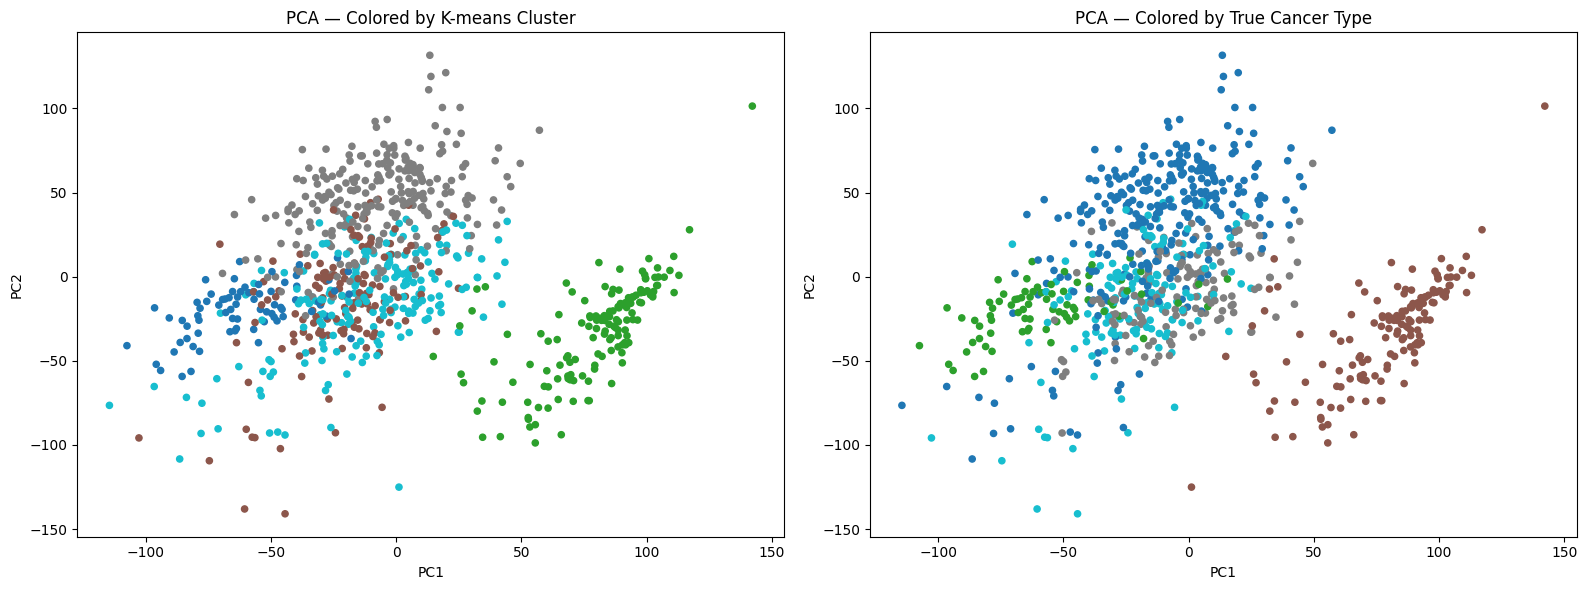

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# 2D PCA for visualisation
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

true_labels_numeric = pd.Categorical(y.values.ravel()).codes

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=cluster_labels, cmap='tab10', s=20)
axes[0].set_title('PCA — Colored by K-means Cluster')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

scatter2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=true_labels_numeric, cmap='tab10', s=20)
axes[1].set_title('PCA — Colored by True Cancer Type')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

The two plots back up what the crosstab already showed. The groups on the right and bottom-left, the two cleanly separated cancer types, look almost identical between the K-means and true-label plots, same shape, same patients. The middle is where it gets messier: in the true-label plot it's a dense overlapping blob, and in the K-means plot that same area gets carved up differently. That's basically the BRCA/LUAD mixing from the crosstab showing up visually. Makes sense too, the cases that are genuinely hard to separate biologically are also the ones that are hard to separate visually, which is reassuring rather than concerning, it means the clustering picked up on something real rather than just noise.

#### t-SNE Visualisation

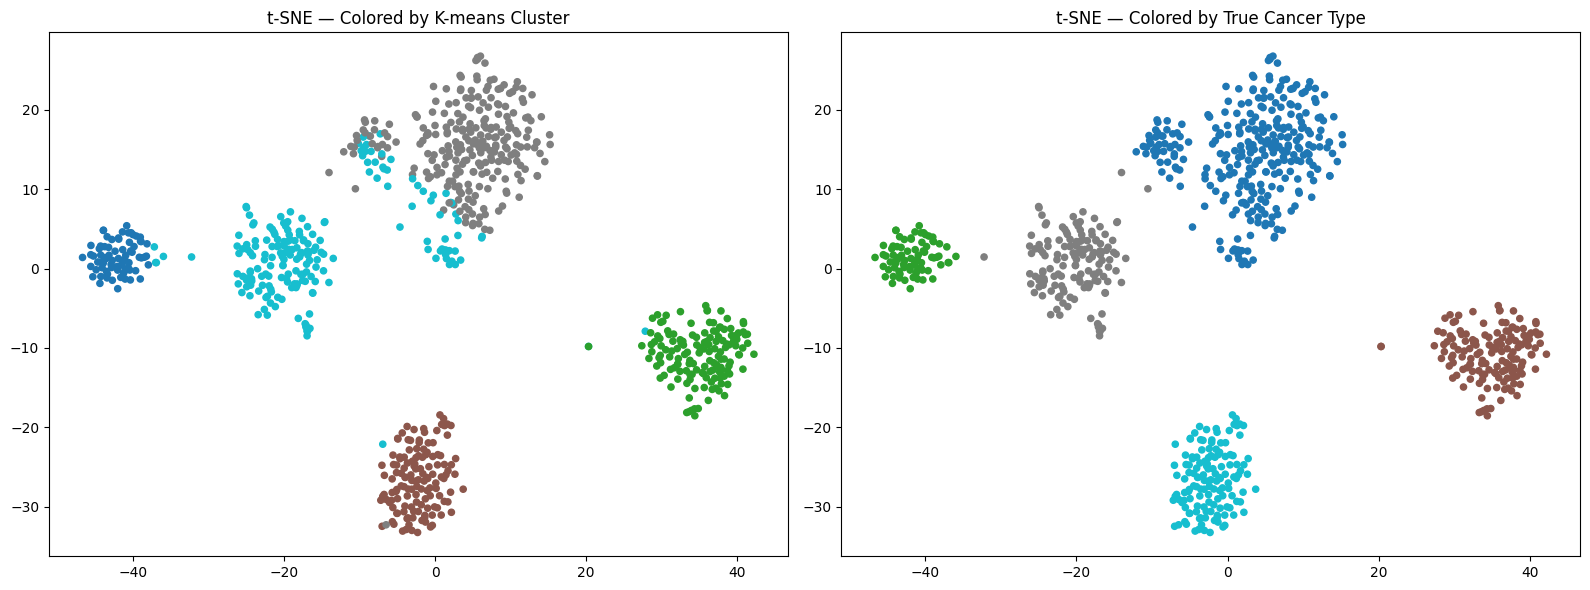

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels, cmap='tab10', s=20)
axes[0].set_title('t-SNE — Colored by K-means Cluster')

scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=true_labels_numeric, cmap='tab10', s=20)
axes[1].set_title('t-SNE — Colored by True Cancer Type')

plt.tight_layout()
plt.show()

t-SNE gives a much cleaner picture than PCA, which makes sense since it's built specifically to preserve local structure. Four of the five groups form tight, clearly separated clusters in both plots, same positions, same shapes, whether you colour by K-means cluster or true cancer type. So those four cancer types are genuinely distinguishable from gene expression alone, no ambiguity there.

The one exception is that region in the upper-middle. In the K-means plot it's one cluster, but in the true-label plot that same spot is actually a mix of two different cancer types overlapping. Same BRCA/LUAD story from the crosstab and PCA plots, just showing up again here. The fact that even t-SNE, which is specifically designed to pull apart local structure, still can't cleanly separate these two, that's a pretty strong sign this isn't just a visualisation issue. These two groups probably do share real overlap in their gene expression, rather than the algorithm just failing to tell them apart.

## Conclusion

This project set out to test whether unsupervised clustering, using nothing but gene expression data, could rediscover the five known cancer types in this dataset without ever being told the diagnosis. The short answer is: mostly yes, and in some cases, very precisely.

K-means with k=5 achieved an Adjusted Rand Index of 0.794 against the true labels. Three cancer types, COAD, KIRC, and PRAD, were separated almost perfectly, with clusters made up of a single cancer type. A fourth, BRCA, was mostly clean too, with the vast majority of patients grouped correctly.

The main source of disagreement came from a subset of BRCA patients grouping instead with LUAD patients, both in the crosstab and visually in the PCA and t-SNE plots. Rather than treating this as a failure of the method, it's a genuinely interesting finding, one that lines up with real, documented biology: breast cancer isn't molecularly uniform, and some cases share more in common with other cancer types than with typical breast cancer. Unsupervised clustering picked up on that complexity without being told to look for it.

It's also worth being upfront about a tension in this project: the three internal clustering metrics used to find the "optimal" k, Silhouette, Elbow, and the dendrogram, disagreed with each other and with the known answer of 5. That disagreement wasn't ignored or hidden, it was used as the actual justification for choosing k=5 deliberately, to directly test the research question rather than chase whichever k scored best internally. That distinction, between finding the mathematically optimal clustering versus testing a specific hypothesis, was one of the more useful things to come out of this project.

## Limitations & Future Work

This project used a pre-cleaned benchmark dataset with dummy gene names instead of real gene identifiers, so I couldn't look into which specific genes actually drove the clustering. A natural next step would be pulling the real gene names from the original TCGA submission and seeing which genes are actually responsible for separating, or failing to separate, BRCA and LUAD.

The 183 PCA components were chosen based on the standard 80% variance convention, which was a reasonable default but wasn't actually tested against clustering performance directly. Trying a few different component counts and comparing ARI scores would be worth doing as a follow-up.

This project also only tested one clustering algorithm and one validation method. Comparing against something like Gaussian Mixture Models, which allow softer, overlapping cluster boundaries, could be genuinely interesting given the BRCA/LUAD overlap found here.

# Phase 2: Biological investigation using gene-identifiable TCGA data

Phase 1 showed that gene-expression profiles can separate most of the five cancer types reasonably well, with an ARI of 0.794. However, there was noticeable overlap between BRCA and LUAD, with a group of BRCA samples clustering alongside LUAD.

The current dataset cannot be used to investigate this further because the gene identifiers are anonymous. This means I can observe the pattern but cannot determine which genes or biological processes may be contributing to it.

In Phase 2, I will use gene-identifiable TCGA expression data for the same five cancer types (BRCA, LUAD, KIRC, COAD and PRAD), together with sample metadata. The aim is first to determine whether the clustering pattern remains when using a more appropriate transcriptomic workflow, and then investigate the genes and biological pathways associated with cancer-type separation and the BRCA/LUAD overlap.